In [1]:
# import cv2
# import numpy as np

# mask_dir = 'PIV/ErrorBasedThreshold_sPCA/data/mask_2D2C_2014.12_W100_10_V1ms_PD350_B00001_A.png'
# mask = cv2.imread(mask_dir)[:,:,0]/255
# mask = mask[:,8:-8] # evaluation excludes 8 px on each side of the image in x
# mask[mask == 0] = np.nan # (nan=wall)

# wall_RAFT = np.zeros(np.shape(mask)[-1]).astype(int)
# for i in range(np.shape(mask)[1]):
#     # print(np.argwhere(np.isnan(mask[:,i]) == True))
#     idx = np.argwhere(np.isnan(mask[:,i]) == True)[-1][0]
#     mask[idx,i] = 1.0
#     wall_RAFT[i] = (idx - 1)

# np.save('PIV/ErrorBasedThreshold_sPCA/data/wall_Raft.npy', wall_RAFT)
# np.save('PIV/ErrorBasedThreshold_sPCA/data/mask.npy', mask)

In [2]:
import h5py
# import jax
# jax.config.update("jax_enable_x64", True)
# from jax import numpy as jnp
# from jax import jit ,vmap
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
# from scipy.signal import convolve2d, fftconvolve # check jax
# from jax.scipy.signal import fftconvolve
# from jax.scipy.interpolate import RegularGridInterpolator
# from jax.scipy.ndimage import map_coordinates
import time

import os
import numpy
import numpy as np

from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture # jaxxx??? # Hyakkk
from sklearn.decomposition import SparsePCA
from scipy.io import loadmat
import matplotlib as mpl
from matplotlib.colors import ListedColormap
# Seaborn colormap
import seaborn as sns
sns_list = sns.color_palette('deep').as_hex()
sns_list.insert(0, '#ffffff')  # Insert white at zero position
sns_cmap = ListedColormap(sns_list)
# import cv2
cm = sns_cmap

mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']


# Calibration used in both weak and pointwise quant comparisons of the wavy wall

In [5]:
wall_RAFT = np.load('PIV/plotting/data/wall_Raft.npy')
mask = np.load('PIV/plotting/data/mask.npy')

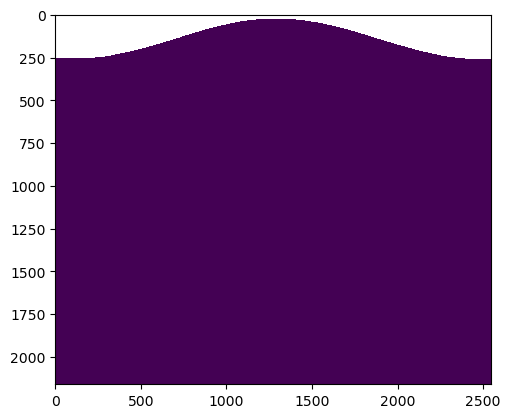

In [3]:
plt.imshow(mask)

In [13]:
# isolate the first row with non_zero
np.count_nonzero(np.isnan(mask[0,:]))
mask_int = (~np.isnan(mask)).astype(int)
fully_non_zero_rows = np.any(mask_int != 0, axis=1)
first_row_idx = np.argmax(fully_non_zero_rows)
col_indices = np.where(mask[first_row_idx] == 1)[0]

flat_trough_radius = (col_indices[-1]-col_indices[0])/2

In [93]:
col_indices

array([1273, 1274, 1275, 1276, 1277, 1278, 1279, 1280, 1281, 1282, 1283,
       1284, 1285, 1286, 1287, 1288, 1289, 1290, 1291, 1292, 1293, 1294,
       1295, 1296, 1297, 1298, 1299, 1300, 1301, 1302, 1303, 1304, 1305,
       1306, 1307, 1308, 1309, 1310, 1311, 1312, 1313, 1314, 1315, 1316,
       1317])

In [96]:
first_row_idx

21

In [95]:
col_indices[0] + flat_trough_radius

1295.0

In [88]:
# isolate the last row with some zero, to find the "crest"
crest_row = np.all(mask_int != 0, axis=1)
crest_row_idx_unadjusted = np.argmax(crest_row)-1
crest_row_col_indices_unadjusted = np.where(mask_int[crest_row_idx_unadjusted] == 0)

In [89]:
crest_row_col_indices_unadjusted

(array([2460, 2461, 2462, 2463, 2464, 2465, 2466, 2467, 2468, 2469, 2470,
        2471, 2472, 2473, 2474, 2475, 2476, 2477, 2478, 2479, 2480, 2481,
        2482, 2483, 2484, 2485, 2486, 2487, 2488, 2489, 2490, 2491, 2492,
        2493, 2494, 2495, 2496, 2497, 2498, 2499]),)

In [90]:
right_crest_radius = (2499-2460)/2
print(right_crest_radius)

19.5


In [91]:
crest_row_idx_unadjusted

259

In [83]:
# isolate the last row with some zero, to find the "crest"
crest_row = np.all(mask_int != 0, axis=1)
crest_row_idx = np.argmax(crest_row) - 7 # manual adjustment since the crests don't line up
crest_row_col_indices = np.where(mask_int[crest_row_idx] == 0)

In [84]:
crest_row_col_indices

(array([  67,   68,   69,   70,   71,   72,   73,   74,   75,   76,   77,
          78,   79,   80,   81,   82,   83,   84,   85,   86,   87,   88,
          89,   90,   91,   92,   93,   94,   95,   96,   97,   98,   99,
         100,  101,  102,  103,  104,  105,  106,  107,  108,  109,  110,
         111,  112,  113,  114,  115,  116,  117,  118,  119,  120,  121,
         122,  123,  124,  125,  126,  127,  128,  129,  130,  131,  132,
         133,  134,  135,  136,  137,  138, 2386, 2387, 2388, 2389, 2390,
        2391, 2392, 2393, 2394, 2395, 2396, 2397, 2398, 2399, 2400, 2401,
        2402, 2403, 2404, 2405, 2406, 2407, 2408, 2409, 2410, 2411, 2412,
        2413, 2414, 2415, 2416, 2417, 2418, 2419, 2420, 2421, 2422, 2423,
        2424, 2425, 2426, 2427, 2428, 2429, 2430, 2431, 2432, 2433, 2434,
        2435, 2436, 2437, 2438, 2439, 2440, 2441, 2442, 2443, 2444, 2445,
        2446, 2447, 2448, 2449, 2450, 2451, 2452, 2453, 2454, 2455, 2456,
        2457, 2458, 2459, 2460, 2461, 

In [85]:
left_crest_radius = (137-67)/2
print(left_crest_radius)

35.0


In [86]:
67 +35

102

^^ kinda seems like an outlier...?

either way, if the right crest is higher than the left crest, I think we should go based of the higher crest since we don't have information for it below the crest...

we can just use this information to center the left crest at pixel # 102 whereas the right would be 2479.5... we'll call it 2480

y-position for the crest wold be pixel 260? then

so we can plug in: 
(x_crest_left, y_crest_left) = (102, 260)
(x_crest_right, y_crest_right) = (2480, 260)
(x_trough, y_trough) = (1295, 21)
?

In [101]:
(2480 - 102)/2 + 102

1291.0

^^ pretty closely aligned too! I guess maybe we make 110 the left coord? just so we align center and right, since the left was a little wonky anyways...


so we can plug in: 
(x_crest_left, y_crest_left) = (110, 260)
(x_crest_right, y_crest_right) = (2480, 260)
(x_trough, y_trough) = (1295, 21)

In [105]:
# PIV trough 2 x amplitutude:
260-21

239